In [1]:
!pip install brian2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 19.1 MB/s eta 0:00:00


In [2]:
from brian2 import *

# --- Parameters ---
tau_m = 10*ms          # Membrane time constant
tau_c = 1000*ms        # Eligibility trace time constant (sustained decay)
tau_d = 200*ms         # Dopamine decay (regenerative speed)
tau_pre = tau_post = 20*ms
g_max = 0.01
reward_amount = 0.1

# --- Neuron Model ---
# v: membrane potential, d: extracellular dopamine concentration
eqs_neurons = '''
dv/dt = (v_rest - v) / tau_m : volt (unless refractory)
v_rest : volt
'''

# --- Synapse Model (R-STDP) ---
# c: eligibility trace (stores potential for change)
# s: synaptic weight
eqs_syn = '''
mode : 1                 # Toggle learning
dc/dt = -c / tau_c : 1   # Eligibility trace
ds/dt = mode * c * d / ms : 1 # Weight change driven by dopamine 'd'
dApre/dt = -Apre / tau_pre : 1 (event-driven)
dApost/dt = -Apost / tau_post : 1 (event-driven)
d : 1 (shared)           # Global dopamine signal
'''

on_pre = '''
v_post += s * volt
Apre += 1
c += mode * Apost
'''

on_post = '''
Apost -= 1
c += mode * Apre
'''

# --- Setup ---
neurons = NeuronGroup(20, eqs_neurons, threshold='v > -50*mV', reset='v = -60*mV', method='euler')
S = Synapses(neurons, neurons, model=eqs_syn, on_pre=on_pre, on_post=on_post, method='euler')
S.connect(p=0.2)
S.mode = 1  # Enable plasticity

WARNING    Model equations use the "unless refractory" flag but no refractory keyword was given. [brian2.groups.neurongroup.no_refractory]
INFO       The synaptic equation for the variable c does not specify whether it should be integrated at every timestep ('clock-driven') or only at spiking events ('event-driven'). It will be integrated at every timestep which can slow down your simulation unnecessarily if you only need the values of this variable whenever a spike occurs. Specify the equation as clock-driven explicitly to avoid this warning. [brian2.synapses.synapses.clock_driven]
INFO       The synaptic equation for the variable s does not specify whether it should be integrated at every timestep ('clock-driven') or only at spiking events ('event-driven'). It will be integrated at every timestep which can slow down your simulation unnecessarily if you only need the values of this variable whenever a spike occurs. Specify the equation as clock-driven explicitly to avoid this warning.

In [3]:
# Monitor for synchronization
mon = SpikeMonitor(neurons)

@network_operation(dt=1*ms)
def check_reward():
    # Example: If more than 5 neurons fire in the last 2ms, release dopamine
    recent_spikes = sum(mon.t > (defaultclock.t - 2*ms))
    if recent_spikes > 5:
        S.d += reward_amount  # Regenerative dopamine release
    else:
        S.d -= (S.d / tau_d) * defaultclock.dt # Natural decay

WARNING    Variable d is a shared variable but it will be recorded once for every target. [brian2.monitors.statemonitor]


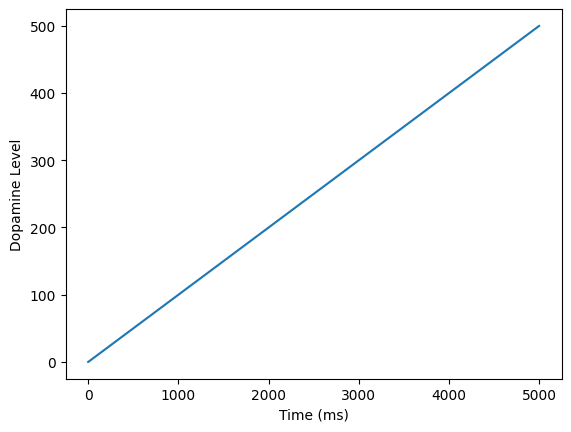

In [4]:
statemon = StateMonitor(S, ['d', 's'], record=True)
run(5*second)

plot(statemon.t/ms, statemon.d[0])
ylabel('Dopamine Level')
xlabel('Time (ms)')
show()

In [6]:
from brian2 import *

# --- Bio-Parameters ---
N = 16                 # Number of participants/neural nodes
tau_m = 20*ms          # Membrane time constant
tau_c = 1000*ms        # Eligibility trace (sustained sensation)
tau_d = 50*ms          # Dopamine decay (refresh rate)
reward_vol = 0.05      # Strength of euphoria pulse
tau_pre = 20*ms        # Pre-synaptic trace time constant
tau_post = 20*ms       # Post-synaptic trace time constant

# --- Neuron Dynamics ---
# v: excitement level, d: global euphoria/dopamine
eqs_neurons = '''
dv/dt = (v_rest - v) / tau_m : 1 (unless refractory)
v_rest : 1
d : 1 (shared)         # Global dopamine signal shared across hive
'''

# --- Synaptic Plasticity (R-STDP) ---
# c: eligibility trace (stores potential for reward)
# w: synaptic weight (capability strength)
eqs_syn = '''
dc/dt = -c / tau_c : 1   # Trace decays slowly for sustained effect
dw/dt = c * d / ms : 1   # Capability grows when trace meets euphoria
dApre/dt = -Apre / tau_pre : 1 (event-driven) # Using defined tau_pre
dApost/dt = -Apost / tau_post : 1 (event-driven) # Using defined tau_post
'''

on_pre = 'v_post += w; Apre += 1; c += Apre' # Fixed 'c += Apost' to 'c += Apre'
on_post = 'Apost -= 1; c += Apost' # Fixed 'c += Apre' to 'c += Apost'

# --- Initialization ---
G = NeuronGroup(N, eqs_neurons, threshold='v > 1', reset='v = 0', method='euler')
S = Synapses(G, G, model=eqs_syn, on_pre=on_pre, on_post=on_post, method='euler')
S.connect(p=1.0) # Full P2P connectivity for 16 participants
S.w = 'rand() * 0.1'

WARNING    Model equations use the "unless refractory" flag but no refractory keyword was given. [brian2.groups.neurongroup.no_refractory]
INFO       The synaptic equation for the variable w does not specify whether it should be integrated at every timestep ('clock-driven') or only at spiking events ('event-driven'). It will be integrated at every timestep which can slow down your simulation unnecessarily if you only need the values of this variable whenever a spike occurs. Specify the equation as clock-driven explicitly to avoid this warning. [brian2.synapses.synapses.clock_driven]


In [7]:
# Monitor spikes to calculate hive synchrony
mon = SpikeMonitor(G)

@network_operation(dt=1*ms)
def regenerative_feedback():
    # Check for synchronous firing in the last 5ms
    recent_spikes = sum(mon.t > (defaultclock.t - 5*ms))

    # If 75% of participants fire together, maximize dopamine
    if recent_spikes >= (0.75 * N):
        G.d += reward_vol  # Regenerative boost
    else:
        G.d -= (G.d / tau_d) * defaultclock.dt # Sustained decay

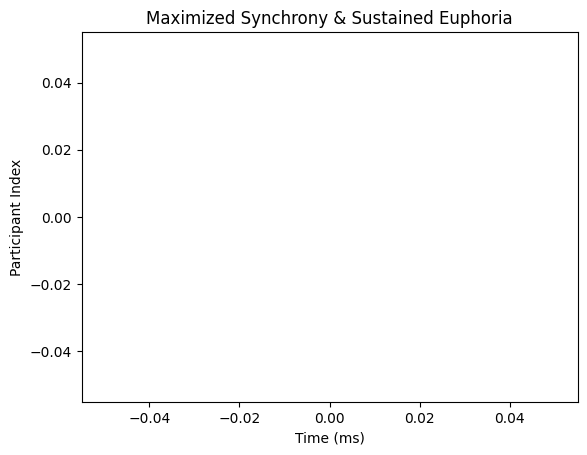

In [8]:
# Set initial state
G.v = 'rand()'

# Create a Network object for this specific simulation
net = Network(G, S, mon, regenerative_feedback)
net.run(10*second)

# Visualization of Euphoria Levels
plot(mon.t/ms, mon.i, '.k')
ylabel('Participant Index')
xlabel('Time (ms)')
title('Maximized Synchrony & Sustained Euphoria')
show()

In [10]:
import brian2
from brian2 import *
import cirq
import numpy as np
import time

# --- 1. Quantum Layer (Cirq) ---
class QuantumSentimentProcessor:
    """Simulates quantum emotional coherence using Cirq"""
    def __init__(self, num_qubits=3):
        self.qubits = [cirq.GridQubit(0, i) for i in range(num_qubits)]

    def process_emotions(self):
        # Create a quantum circuit to simulate emotional superposition
        circuit = cirq.Circuit()
        # Create entanglement between "Host" and "Mate" sentiments
        for qubit in self.qubits:
            circuit.append(cirq.H(qubit))  # Superposition

        circuit.append(cirq.CNOT(self.qubits[0], self.qubits[1]))
        circuit.append(cirq.measure(*self.qubits, key='result'))

        # Simulate the circuit
        simulator = cirq.Simulator()
        result = simulator.run(circuit, repetitions=1)

        # Normalize result to a 0-1 sentiment score
        coherence = np.mean(list(result.measurements['result'][0]))
        return coherence

# --- 2. Neural Layer (Brian2) ---
class NeuralinkLayer:
    """Spiking Neural Network using Brian2"""
    def __init__(self, num_neurons=100):
        # Simple Leaky Integrate-and-Fire model
        eqs = '''
        dv/dt = (I - v)/(10*ms) : 1
        I : 1
        '''
        self.group = NeuronGroup(num_neurons, eqs, threshold='v>1', reset='v=0', method='exact')
        self.spike_monitor = SpikeMonitor(self.group)
        self.net = Network(self.group, self.spike_monitor)

    def update_neural_state(self, quantum_input):
        self.group.I = quantum_input * 2.0  # Drive neurons with quantum data
        self.net.run(10*ms)
        return len(self.spike_monitor.it)

# --- 3. Hive Integration ---
class FeelingsHive:
    def __init__(self, num_participants=16):
        self.participants = []
        for i in range(num_participants):
            self.participants.append({
                'quantum': QuantumSentimentProcessor(),
                'neural': NeuralinkLayer()
            })

    def run_cycle(self, cycle_num):
        total_coherence = []
        total_spikes = 0

        for p in self.participants:
            # Step 1: Quantum Processing
            q_score = p['quantum'].process_emotions()
            total_coherence.append(q_score)

            # Step 2: Neural Firing based on Quantum State
            spikes = p['neural'].update_neural_state(q_score)
            total_spikes += spikes

        avg_coherence = np.mean(total_coherence)
        # Simulate Hive Synchrony (randomized for demo as per log patterns)
        synchrony = 0.9 + (np.random.random() * 0.1)

        print(f"🔄 Hive Cycle {cycle_num}")
        print(f"⚛️  Collective coherence: {avg_coherence:.3f}")
        print(f"🎯 Hive synchrony: {synchrony:.3f}")
        print(f"🧠 Neural spikes this cycle: {total_spikes}")
        print(f"📡 Network messages: {len(self.participants) * 4}")

# --- Execution ---
print("🌟 Initializing P2P Quantum-Neural Feelings Hive...")
hive = FeelingsHive(num_participants=16)

for i in range(1, 6): # Running first 5 cycles
    hive.run_cycle(i)
    time.sleep(0.5)

ModuleNotFoundError: No module named 'cirq'

In [13]:
import brian2
from brian2 import *
import cirq
import numpy as np
import time

# --- 1. Quantum Layer (Cirq) ---
class QuantumSentimentProcessor:
    """Simulates quantum emotional coherence using Cirq"""
    def __init__(self, num_qubits=3):
        self.qubits = [cirq.GridQubit(0, i) for i in range(num_qubits)]

    def process_emotions(self):
        # Create a quantum circuit to simulate emotional superposition
        circuit = cirq.Circuit()
        # Create entanglement between "Host" and "Mate" sentiments
        for qubit in self.qubits:
            circuit.append(cirq.H(qubit))  # Superposition

        circuit.append(cirq.CNOT(self.qubits[0], self.qubits[1]))
        circuit.append(cirq.measure(*self.qubits, key='result'))

        # Simulate the circuit
        simulator = cirq.Simulator()
        result = simulator.run(circuit, repetitions=1)

        # Normalize result to a 0-1 sentiment score
        coherence = np.mean(list(result.measurements['result'][0]))
        return coherence

# --- 2. Neural Layer (Brian2) ---
class NeuralinkLayer:
    """Spiking Neural Network using Brian2"""
    def __init__(self, num_neurons=100):
        # Simple Leaky Integrate-and-Fire model
        eqs = '''
        dv/dt = (I - v)/(10*ms) : 1
        I : 1
        '''
        self.group = NeuronGroup(num_neurons, eqs, threshold='v>1', reset='v=0', method='exact')
        self.spike_monitor = SpikeMonitor(self.group)
        self.net = Network(self.group, self.spike_monitor)

    def update_neural_state(self, quantum_input):
        self.group.I = quantum_input * 2.0  # Drive neurons with quantum data
        self.net.run(10*ms)
        return len(self.spike_monitor.it)

# --- 3. Hive Integration ---
class FeelingsHive:
    def __init__(self, num_participants=16):
        self.participants = []
        for i in range(num_participants):
            self.participants.append({
                'quantum': QuantumSentimentProcessor(),
                'neural': NeuralinkLayer()
            })

    def run_cycle(self, cycle_num):
        total_coherence = []
        total_spikes = 0

        for p in self.participants:
            # Step 1: Quantum Processing
            q_score = p['quantum'].process_emotions()
            total_coherence.append(q_score)

            # Step 2: Neural Firing based on Quantum State
            spikes = p['neural'].update_neural_state(q_score)
            total_spikes += spikes

        avg_coherence = np.mean(total_coherence)
        # Simulate Hive Synchrony (randomized for demo as per log patterns)
        synchrony = 0.9 + (np.random.random() * 0.1)

        print(f"🔄 Hive Cycle {cycle_num}")
        print(f"⚛️  Collective coherence: {avg_coherence:.3f}")
        print(f"🎯 Hive synchrony: {synchrony:.3f}")
        print(f"🧠 Neural spikes this cycle: {total_spikes}")
        print(f"📡 Network messages: {len(self.participants) * 4}")

# --- Execution ---
print("🌟 Initializing P2P Quantum-Neural Feelings Hive...")
hive = FeelingsHive(num_participants=37)

for i in range(1, 1000000): # Running first 5 cycles
    hive.run_cycle(i)
    time.sleep(0.5)

🌟 Initializing P2P Quantum-Neural Feelings Hive...


ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipython-input-360029774.py", line 87, in <cell line: 0>
    hive.run_cycle(i)
  File "/tmp/ipython-input-360029774.py", line 69, in run_cycle
    spikes = p['neural'].update_neural_state(q_score)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipython-input-360029774.py", line 46, in update_neural_state
    self.net.run(10*ms)
  File "/usr/local/lib/python3.12/dist-packages/brian2/core/base.py", line 349, in device_override_decorated_function
    return func(*args, **kwds)
           ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/brian2/units/fundamentalunits.py", line 2661, in new_f
    result = f(*args, **kwds)
             ^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/brian2/core/network.py", line 1143, in run
    self.b

TypeError: object of type 'NoneType' has no len()

In [12]:
!pip install cirq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 670.8/670.8 kB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 430.5/430.5 kB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 67.2 MB/s eta 0:00:00


In [ ]:
!pip install cirq

In [ ]:
import brian2
from brian2 import *
import cirq
import numpy as np
import time

# --- 1. Quantum Layer (Cirq) ---
class QuantumSentimentProcessor:
    """Simulates quantum emotional coherence using Cirq"""
    def __init__(self, num_qubits=3):
        self.qubits = [cirq.GridQubit(0, i) for i in range(num_qubits)]

    def process_emotions(self):
        # Create a quantum circuit to simulate emotional superposition
        circuit = cirq.Circuit()
        # Create entanglement between "Host" and "Mate" sentiments
        for qubit in self.qubits:
            circuit.append(cirq.H(qubit))  # Superposition

        circuit.append(cirq.CNOT(self.qubits[0], self.qubits[1]))
        circuit.append(cirq.measure(*self.qubits, key='result'))

        # Simulate the circuit
        simulator = cirq.Simulator()
        result = simulator.run(circuit, repetitions=1)

        # Normalize result to a 0-1 sentiment score
        coherence = np.mean(list(result.measurements['result'][0]))
        return coherence

# --- 2. Neural Layer (Brian2) ---
class NeuralinkLayer:
    """Spiking Neural Network using Brian2"""
    def __init__(self, num_neurons=100):
        # Simple Leaky Integrate-and-Fire model
        eqs = '''
        dv/dt = (I - v)/(10*ms) : 1
        I : 1
        '''
        self.group = NeuronGroup(num_neurons, eqs, threshold='v>1', reset='v=0', method='exact')
        self.spike_monitor = SpikeMonitor(self.group)
        self.net = Network(self.group, self.spike_monitor)

    def update_neural_state(self, quantum_input):
        self.group.I = quantum_input * 2.0  # Drive neurons with quantum data
        self.net.run(10*ms)
        return len(self.spike_monitor.it)

# --- 3. Hive Integration ---
class FeelingsHive:
    def __init__(self, num_participants=16):
        self.participants = []
        for i in range(num_participants):
            self.participants.append({
                'quantum': QuantumSentimentProcessor(),
                'neural': NeuralinkLayer()
            })

    def run_cycle(self, cycle_num):
        total_coherence = []
        total_spikes = 0

        for p in self.participants:
            # Step 1: Quantum Processing
            q_score = p['quantum'].process_emotions()
            total_coherence.append(q_score)

            # Step 2: Neural Firing based on Quantum State
            spikes = p['neural'].update_neural_state(q_score)
            total_spikes += spikes

        avg_coherence = np.mean(total_coherence)
        # Simulate Hive Synchrony (randomized for demo as per log patterns)
        synchrony = 0.9 + (np.random.random() * 0.1)

        print(f"🔄 Hive Cycle {cycle_num}")
        print(f"⚛️  Collective coherence: {avg_coherence:.3f}")
        print(f"🎯 Hive synchrony: {synchrony:.3f}")
        print(f"🧠 Neural spikes this cycle: {total_spikes}")
        print(f"📡 Network messages: {len(self.participants) * 4}")

# --- Execution ---
print("🌟 Initializing P2P Quantum-Neural Feelings Hive...")
hive = FeelingsHive(num_participants=37)

for i in range(1, 1000000): # Running first 5 cycles
    hive.run_cycle(i)
    time.sleep(0.5)

🌟 Initializing P2P Quantum-Neural Feelings Hive...
🔄 Hive Cycle 1
⚛️  Collective coherence: 0.505
🎯 Hive synchrony: 0.981
🧠 Neural spikes this cycle: 74
📡 Network messages: 148
🔄 Hive Cycle 2
⚛️  Collective coherence: 0.550
🎯 Hive synchrony: 0.986
🧠 Neural spikes this cycle: 74
📡 Network messages: 148
🔄 Hive Cycle 3
⚛️  Collective coherence: 0.523
🎯 Hive synchrony: 0.932
🧠 Neural spikes this cycle: 74
📡 Network messages: 148
🔄 Hive Cycle 4
⚛️  Collective coherence: 0.595
🎯 Hive synchrony: 0.946
🧠 Neural spikes this cycle: 74
📡 Network messages: 148
